# Pal 5 perturbed by a rotating Dehnen bar

Chen+25 particle-spray Pal 5 stream in gala's `MilkyWayPotential2022`, with and without a rotating
`DehnenBarPotential`. The bar is the perturbation: $\Delta v_r$ is the barred stream's $v_r$ minus a
polynomial fit to the unperturbed (no-bar) $v_r(\phi_1)$ track.

In [2]:
import streamsculptor as ssc
from streamsculptor import potential



import jax
import jax.numpy as jnp
import numpy as np
import diffrax


import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord, Galactocentric
import gala.coordinates as gc


jax.config.update("jax_enable_x64", True)

### potential

`MilkyWayPotential2022` (gala)

In [3]:
mw = potential.GalaMilkyWayPotential(units=ssc.usys)

### Dehnen bar

Quadrupole bar of Dehnen (2000): pure $m=2$ term, so it adds no mass and the axisymmetric MW is unchanged.

Also described here: https://arxiv.org/abs/2410.21174
- `alpha = 0.01`: bar-to-axisymmetric radial force ratio at $R_0$ (Dehnen 2000)
- `v0`: circular velocity of the MW model at $R_0$ (astropy's default `Galactocentric` distance)
- `Rb = 3.5` kpc bar length
- `phib = -27 deg`: long axis 27° from the Sun–GC line, near end at positive $l$. Present-day angle at $t=0$.
- `Omega = -41 km/s/kpc`: in astropy's Galactocentric frame the disk rotates clockwise ($L_z<0$), so the
  pattern speed is negative. The bar angle is `phib + Omega * t`.

In [34]:
gcf = Galactocentric()
R0 = gcf.galcen_distance.to_value(u.kpc)
print(R0)

v0 =  jnp.sqrt(R0 * jnp.linalg.norm(mw.acceleration(jnp.array([R0, 0.0, 0.0]), 0.0)))  # kpc/Myr

# pattern speed
Omega_b = (-38.0 * u.km / u.s / u.kpc).to_value(1 / u.Myr)

bar = potential.DehnenBarPotential(alpha=0.08, v0=v0, R0=R0, Rb=3.5,
                                   phib=jnp.deg2rad(-27.0), Omega=Omega_b, units=ssc.usys)


                                   
mw_bar = potential.Potential_Combine([mw, bar], units=ssc.usys)

print(f"v_c(R0) = {v0 * (u.kpc / u.Myr).to(u.km / u.s):.1f} km/s")

8.122
v_c(R0) = 231.5 km/s


### Pal 5 progenitor

Present-day phase-space position from Vasiliev & Baumgardt (2021) / Baumgardt & Vasiliev (2021),
converted to Galactocentric Cartesian (kpc, kpc/Myr).

In [35]:
pal5 = SkyCoord(ra=229.019167 * u.deg, dec=-0.121 * u.deg, distance=21.94 * u.kpc,
                pm_ra_cosdec=-2.754 * u.mas / u.yr, pm_dec=-2.643 * u.mas / u.yr,
                radial_velocity=-58.61 * u.km / u.s).transform_to(gcf)

prog_wtoday = jnp.array([*pal5.cartesian.xyz.to_value(u.kpc),
                         *pal5.velocity.d_xyz.to_value(u.kpc / u.Myr)])
prog_wtoday

Array([ 7.19709249e+00,  2.23687708e-01,  1.57255695e+01, -4.86482233e-02,
       -1.54166780e-01, -9.68690811e-03], dtype=float64)

### generate the streams

For each potential, integrate the progenitor back from today, then forward-generate the Chen+25 stream.
Same `ts` and `key` in both so the particles line up. `ts[-1] = 0` is the present.

In [36]:
t_age = 5000.0  # Myr

# total number of particles is N_strip * 2, since we generate two strips (leading and trailing)
N_strip = 3000
ts = jnp.linspace(-t_age, 0.0, N_strip)
Msat = 2e4
key = jax.random.PRNGKey(0)



def make_stream(pot):
    IC = pot.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age, ts=jnp.array([-t_age]),
                             solver=diffrax.Dopri8(), rtol=1e-8, atol=1e-8).ys[0]


                             
    l, t = ssc.gen_stream_Chen25(pot_base=pot, ts=ts, prog_w0=IC, Msat=Msat, key=key,
                                 solver=diffrax.Dopri8(), rtol=1e-7, atol=1e-7, dtmin=0.1)
    return jnp.vstack([l, t])

stream_nobar = make_stream(mw)
stream_bar = make_stream(mw_bar)

In [37]:
stream_nobar.shape

(5998, 6)

### Pal 5 stream coordinates

Transform to gala's `Pal5PriceWhelan18` frame; $v_r$ is heliocentric line-of-sight velocity.

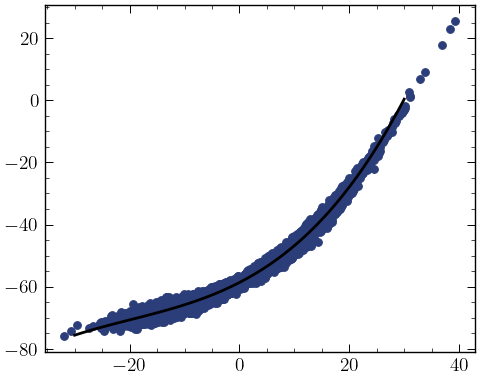

In [39]:
def to_pal5_frame(w):
    gal = Galactocentric(x=w[:, 0] * u.kpc, y=w[:, 1] * u.kpc, z=w[:, 2] * u.kpc,
                         v_x=w[:, 3] * u.kpc / u.Myr, v_y=w[:, 4] * u.kpc / u.Myr,
                         v_z=w[:, 5] * u.kpc / u.Myr)
    s = SkyCoord(gal).transform_to(gc.Pal5PriceWhelan18())
    return s.phi1.wrap_at(180 * u.deg).deg, s.phi2.deg, s.radial_velocity.to_value(u.km / u.s)

phi1_nb, phi2_nb, vr_nb = to_pal5_frame(stream_nobar)
phi1_b, phi2_b, vr_b = to_pal5_frame(stream_bar)


plt.scatter(phi1_nb,vr_nb)

# unperturbed v_r track: polynomial fit to the no-bar stream (|phi1| < 20 deg drops a few far outliers)
poly_deg = 3
fit_mask = np.abs(phi1_nb) < 20
vr_track = np.poly1d(np.polyfit(phi1_nb[fit_mask], vr_nb[fit_mask], poly_deg))

phi1_lin = jnp.linspace(-30, 30, 100)
v_r_track_plot = vr_track(phi1_lin)

plt.plot(phi1_lin, v_r_track_plot, color='black', lw=2, label='no-bar track')


dvr = vr_b - vr_track(phi1_b)  # km/s

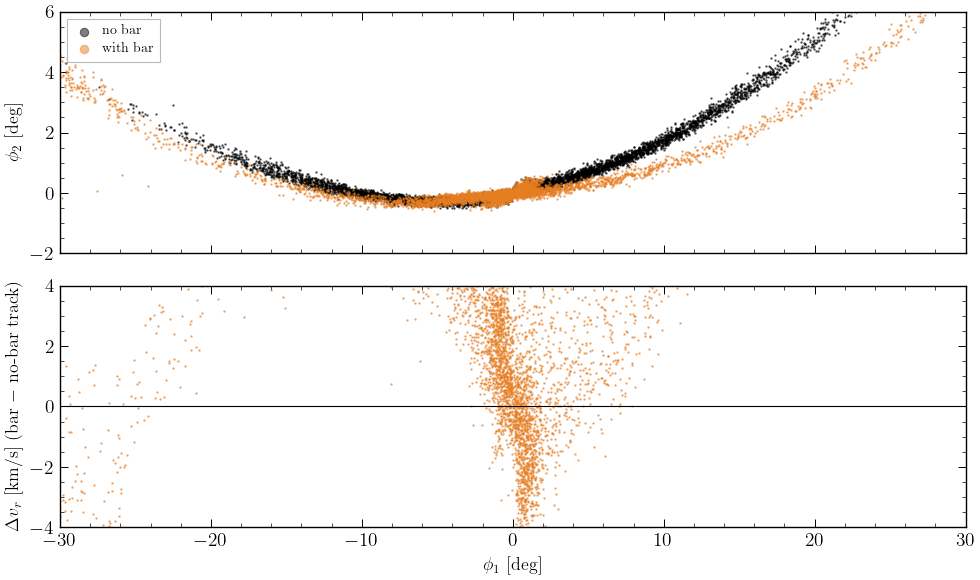

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].scatter(phi1_nb, phi2_nb, s=1, c='k', alpha=0.5, label='no bar')
axes[0].scatter(phi1_b, phi2_b, s=1, c='C3', alpha=0.5, label='with bar')
axes[0].set_ylabel(r'$\phi_2$ [deg]')
axes[0].set_ylim(-2, 6)
axes[0].legend(markerscale=6, loc='upper left')

axes[1].scatter(phi1_b, dvr, s=1, c='C3', alpha=0.5)
axes[1].axhline(0.0, c='k', lw=0.8)
axes[1].set_ylabel(r'$\Delta v_r$ [km/s]  (bar $-$ no-bar track)')
axes[1].set_xlabel(r'$\phi_1$ [deg]')
axes[1].set_xlim(-30, 30)
axes[1].set_ylim(-4, 4)

plt.show()

### scan over bar pattern speed

Same setup, bar pattern speed varied. `make_stream_bar` is jitted with `Omega` traced, so it compiles
once and later calls reuse it. Uses `method="vmap"` since the default CPU active-set integrator isn't
jittable. $\Delta v_r$ is relative to the same no-bar polynomial track.

In [41]:
import equinox as eqx

# some jax stuff to compile the stream generator code
@eqx.filter_jit
def make_stream_bar(Omega):
    """Pal 5 stream in MW + Dehnen bar with pattern speed Omega [1/Myr]. Omega is traced, so one compile."""
    bar_i = potential.DehnenBarPotential(alpha=0.03, v0=v0, R0=R0, Rb=3.5,
                                         phib=jnp.deg2rad(-27.0), Omega=Omega, units=ssc.usys)
    pot = potential.Potential_Combine([mw, bar_i], units=ssc.usys)
    IC = pot.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age, ts=jnp.array([-t_age]),
                             solver=diffrax.Dopri8(), rtol=1e-8, atol=1e-8).ys[0]
    

    l, t = ssc.gen_stream_Chen25(pot_base=pot, ts=ts, prog_w0=IC, Msat=Msat, key=key,
                                 solver=diffrax.Dopri8(), rtol=1e-7, atol=1e-7, dtmin=0.1,
                                 method="vmap")
    return jnp.vstack([l, t])

# omage values to scan over
Omegas_kms_kpc = [-35.0, -41.0, -45.0, -48.0]
kms_kpc_to_Myr = (1.0 * u.km / u.s / u.kpc).to_value(1 / u.Myr)

scan_results = {}
for Om in Omegas_kms_kpc:
    # pass in a jax array as input
    stream_i = make_stream_bar(jnp.asarray(Om * kms_kpc_to_Myr))
    scan_results[Om] = to_pal5_frame(np.asarray(stream_i))

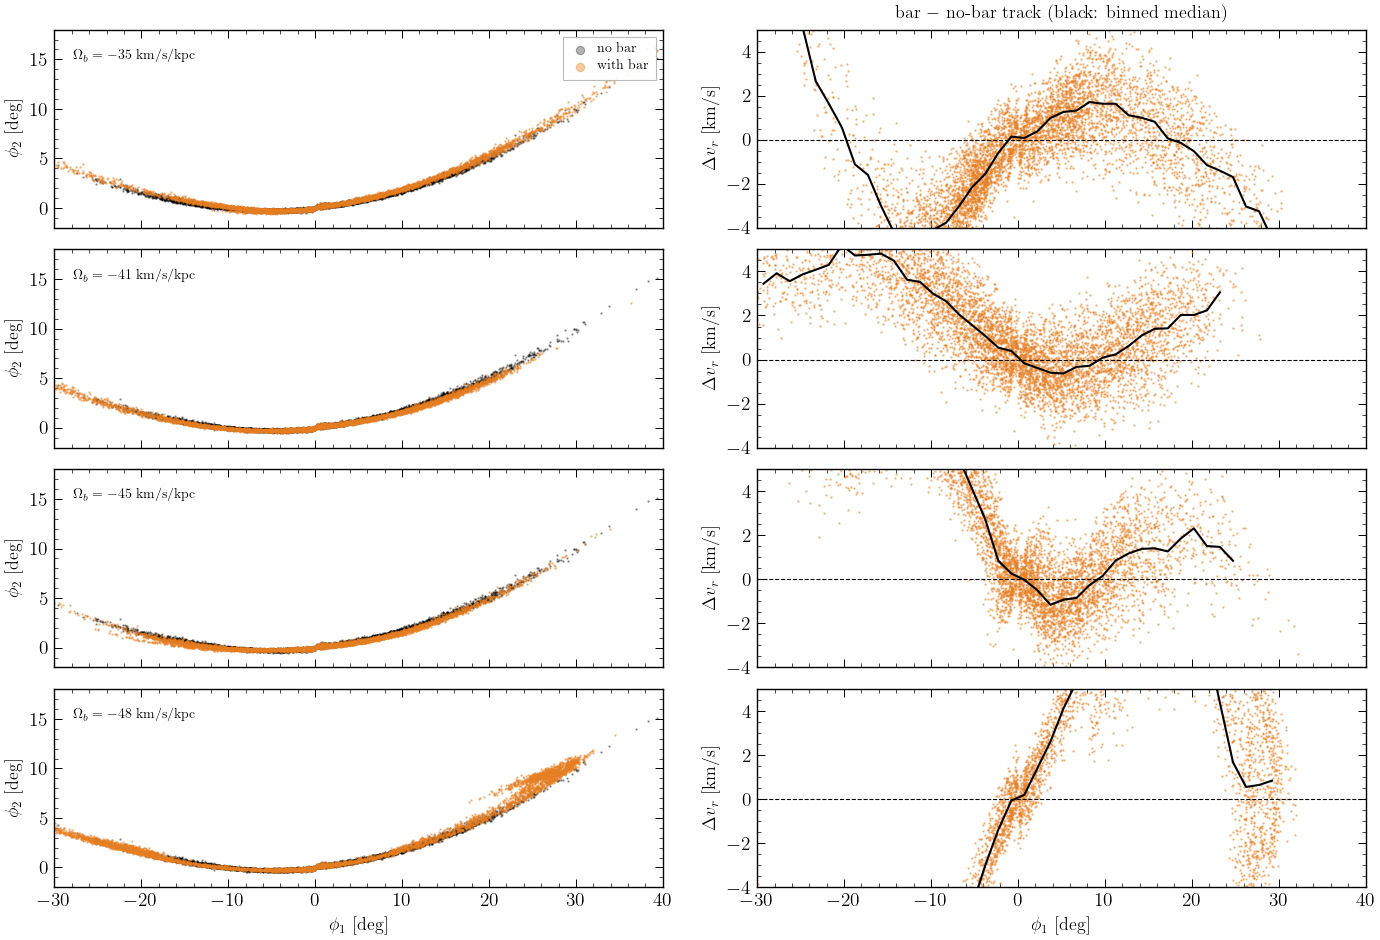

In [47]:
bins = np.linspace(-30, 30, 41)
bin_c = 0.5 * (bins[1:] + bins[:-1])

def binned_median(x, y):
    idx = np.digitize(x, bins) - 1
    return np.array([np.median(y[idx == i]) if np.sum(idx == i) > 10 else np.nan for i in range(len(bin_c))])

fig, axes = plt.subplots(len(Omegas_kms_kpc), 2, figsize=(14, 2.4 * len(Omegas_kms_kpc)), sharex=True)

for row, Om in zip(axes, Omegas_kms_kpc):
    phi1_i, phi2_i, vr_i = scan_results[Om]
    dvr_i = vr_i - vr_track(phi1_i)

    row[0].scatter(phi1_nb, phi2_nb, s=1, c='k', alpha=0.3, label='no bar')
    row[0].scatter(phi1_i, phi2_i, s=1, c='C3', alpha=0.4, label='with bar')
    row[0].set_ylabel(r'$\phi_2$ [deg]')
    row[0].set_ylim(-2, 18)
    row[0].text(0.03, 0.85, rf'$\Omega_b = {Om:.0f}$ km/s/kpc', transform=row[0].transAxes)

    row[1].scatter(phi1_i, dvr_i, s=1, c='C3', alpha=0.4)
    row[1].plot(bin_c, binned_median(phi1_i, dvr_i), c='k', lw=1.5)
    row[1].axhline(0.0, c='k', lw=0.8, ls='--')
    row[1].set_ylabel(r'$\Delta v_r$ [km/s]')
    row[1].set_ylim(-4, 5)

axes[0, 0].legend(markerscale=6, loc='upper right')
axes[0, 1].set_title(r'bar $-$ no-bar track (black: binned median)')
for ax in axes[-1]:
    ax.set_xlabel(r'$\phi_1$ [deg]')
    ax.set_xlim(-30, 40)

plt.show()